In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE

# Data and Overview

In [2]:
df_complete = pd.read_csv(
    "../Data and descriptions/Case Rigshospitalet - Completed operations.csv",
    sep=";"
)
df_cancelled = pd.read_csv(
    "../Data and descriptions/Case Rigshospitalet - Cancelled operations.csv",
    sep=";"
)

/var/folders/hs/9s0b5rgj539chsrz2hkbmzrr0000gn/T/ipykernel_49842/3917172957.py:1: DtypeWarning: Columns (13,14,21,22,23,24,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_complete = pd.read_csv(


In [3]:
df_complete.describe()

,Case-ID Anonymous,Patient Alder,Operationsgang ID,Forsinkelse (minutter),Overskredet (minutter),Staff.Anæstesiolog,Staff.Anæstesisygeplejerske,Staff.Gulvassistent,Staff.Operationssygeplejerske,Staff.Preprocedure Nurse,...,Ressource.Olympus Exera II (anæstesisøjle),Ressource.Sonostar,Ressource.COP3589 A O bøjejern rekonstruktionsskinner,Ressource.BMAC-centrifuge,Ressource.Benchbord,Ressource.Diodelaser næse,Ressource.Øre optik 30°,Ressource.Endoskop,Ressource.Flexcystoskop,Ressource.Kasette
count,133158.000000,133158.000000,133158.000000,132491.000000,132537.000000,74832.0,79227.0,113625.0,119226.0,80560.0,...,2.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,2.0,0.0
mean,60156.037437,53.788244,40663.550909,20.511642,25.346198,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
std,34927.061620,24.889920,52262.972747,50.977296,68.894706,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN
min,1.000000,0.000000,618.000000,-3045.000000,-3003.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
25%,29928.250000,34.000000,622.000000,0.000000,-10.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
50%,60097.500000,61.000000,625.000000,14.000000,23.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
75%,90338.750000,74.000000,107621.000000,40.000000,57.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
max,120868.000000,107.000000,133218.000000,1585.000000,1560.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN


# Delay

In [4]:
frac_delay = len(df_complete[df_complete['Forsinkelse (minutter)'] > 0]) / len(df_complete)
frac_delay_reason = len(df_complete[(df_complete['Forsinkelse (minutter)'] > 0) & 
                                    (df_complete['Forsinkelsesårsag'].notna())]) / len(df_complete['Forsinkelse (minutter)'] > 0)

# Reserve 50 characters for the text so numbers align
print(f"{'Fraction of operations delayed:':50}{frac_delay}")
print(f"{'Fraction of delayed operations with reason:':50}{frac_delay_reason}")

Fraction of operations delayed:                   0.726685591552892
Fraction of delayed operations with reason:       0.024624881719461093


# Initial Cluster

### Set up features

In [5]:
# Convert to date time
daytime_vars = ['Dato', 'Pt ankommet til hospitalet', 'Planlagt stue klargøring start', 
            'Stue klargøring start', 'Stue klargjort', 'Patient på stuen', 
            'Patient på stuen (Planlagt)', 'Anæstesistart', 'Anæstesi melder klar',
            'Procedure start', 'Procedure slut', 'Patient klar til afgang', 
            'Patient forlader stuen (Planlagt)', 'Patient forlader stuen', 'Stue rengjort (Planlagt)',
            'Stue rengøring start', 'Stue rengjort', 'I opvågning', 'Anæstesistop', 
            'Klar til udskrivelse efter opvågning', 'Patient forlader afdeling']
for var in daytime_vars:
    df_complete[var] = pd.to_datetime(df_complete[var], format='%Y-%m-%d %H:%M:%S,%f')

# Add staff amount
staff_columns = [col for col in df_complete.columns if col.startswith("Staff")]
df_complete['Staff amount'] = df_complete[staff_columns].sum(axis=1)

# One hot encoding of "Speciale" and "Akut case" and "Operationsgang ID"
df_complete = pd.get_dummies(df_complete, columns=['Speciale'])
df_complete['Akut case (J/N)'] = df_complete['Akut case (J/N)'].replace({'Ja': 1, 'Nej': 0})
df_complete = pd.get_dummies(df_complete, columns=['Operationsgang ID'])

In [6]:
# Add month variable, where sine and cosine are used to ensure similar features for close months
months = df_complete['Dato'].dt.month
df_complete['Måned_sin'] = np.sin(2 * np.pi * months/12)
df_complete['Måned_cos'] = np.cos(2 * np.pi * months/12)

### Feature selection

In [7]:
daytime_cols_to_drop = ['Dato', 'Pt ankommet til hospitalet', 'Planlagt stue klargøring start',
                        'Stue klargøring start', 'Stue klargjort', 'Patient på stuen (Planlagt)', 
                        'Patient på stuen', 'Anæstesistart', 'Anæstesi melder klar', 'Procedure start', 
                        'Procedure slut', 'Patient klar til afgang', 'Patient forlader stuen (Planlagt)',
                        'Patient forlader stuen', 'Stue rengjort (Planlagt)', 'Stue rengøring start', 
                        'Stue rengjort', 'I opvågning', 'Anæstesistop','Klar til udskrivelse efter opvågning', 
                        'Patient forlader afdeling','Forsinkelsesårsag']
staff_cols_to_drop = [col for col in df_complete.columns if col.startswith("Staff.")]
ressource_cols_to_drop = [col for col in df_complete.columns if col.startswith("Ressource")]
other_cols_to_drop = ['Case-ID Anonymous', 'Stue', 'Procedure - Tekst & ID', 
                      'Aktionsdiagnose - Kode & tekst', 'Aktionsdiagnose - Gruppe']
cols_to_drop = daytime_cols_to_drop + staff_cols_to_drop + ressource_cols_to_drop + other_cols_to_drop
df_cluster = df_complete.drop(columns=cols_to_drop)
print(f"Number of samples before row exclusion: {len(df_cluster)}")

Number of samples before row exclusion: 133158


Exclude cases with missing data

In [9]:
# Drop rows with NaN
df_cluster_clean = df_cluster.dropna()
print(f"Number of samples after row exclusion: {len(df_cluster_clean)}")

Number of samples after row exclusion: 132420


In [10]:
df_cluster_clean

,Patient Alder,Akut case (J/N),Forsinkelse (minutter),Overskredet (minutter),Staff amount,Speciale_Alloplastik,Speciale_Anæstesiologi,Speciale_Brystkirurgi,Speciale_Børnekirurgi,Speciale_Børneortopædi,...,Operationsgang ID_618,Operationsgang ID_620,Operationsgang ID_622,Operationsgang ID_624,Operationsgang ID_625,Operationsgang ID_107621,Operationsgang ID_107622,Operationsgang ID_133218,Måned_sin,Måned_cos
0,29,0,95.0,36.0,5.0,False,False,False,False,False,...,False,False,False,False,False,True,False,False,1.000000e+00,6.123234e-17
1,60,0,8.0,30.0,4.0,False,False,False,False,False,...,False,False,False,False,False,True,False,False,5.000000e-01,8.660254e-01
2,60,0,8.0,30.0,4.0,False,False,False,False,False,...,False,False,False,False,False,True,False,False,5.000000e-01,8.660254e-01
3,12,0,16.0,-3.0,4.0,False,False,False,False,False,...,False,False,False,False,False,True,False,False,5.000000e-01,8.660254e-01
4,57,0,16.0,1.0,3.0,False,False,False,False,False,...,False,False,False,False,False,True,False,False,-8.660254e-01,5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133153,59,0,47.0,51.0,4.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,-2.449294e-16,1.000000e+00
133154,58,0,35.0,40.0,4.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,-2.449294e-16,1.000000e+00
133155,70,0,52.0,52.0,4.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,-2.449294e-16,1.000000e+00
133156,87,0,42.0,50.0,4.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,-2.449294e-16,1.000000e+00


### Do K-Means Clustering 

In [11]:
# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_clean)

# Perform clustering
k = 5
kmeans = KMeans(n_clusters=k, random_state=2026)
kmeans.fit(X_scaled)

# Assign cluster labels to final DataFrame
df_final = df_cluster_clean
df_final['cluster'] = kmeans.labels_

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/var/folders/hs/9s0b5rgj539chsrz2hkbmzrr0000gn/T/ipykernel_49842/897485783.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['cluster'] = kmeans.labels_


Inspect results

In [12]:
# Count of rows per cluster
print(df_final['cluster'].value_counts())

cluster
0    43909
1    40217
2    32618
4    10760
3     4916
Name: count, dtype: int64


In [13]:
# Compare mean values per cluster
cluster_summary = df_final.groupby('cluster').mean()
cluster_summary

,Patient Alder,Akut case (J/N),Forsinkelse (minutter),Overskredet (minutter),Staff amount,Speciale_Alloplastik,Speciale_Anæstesiologi,Speciale_Brystkirurgi,Speciale_Børnekirurgi,Speciale_Børneortopædi,...,Operationsgang ID_618,Operationsgang ID_620,Operationsgang ID_622,Operationsgang ID_624,Operationsgang ID_625,Operationsgang ID_107621,Operationsgang ID_107622,Operationsgang ID_133218,Måned_sin,Måned_cos
cluster,,,,,,,,,,,,,,,,,,,,,
0,46.321346,0.202829,15.055365,18.072423,6.632034,0.008973,0.000137,0.000273,0.000000,0.024733,...,0.000023,0.000023,0.000068,0.0,0.000000,0.909358,0.090528,0.000000,0.015262,0.027138
1,66.517368,0.085262,41.931024,46.357436,4.504886,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000124,0.000075,0.000174,0.0,0.953428,0.010046,0.036079,0.000075,0.020889,0.038967
2,45.872432,0.320437,12.163407,18.784720,5.692378,0.000000,0.003863,0.000031,0.125759,0.000031,...,0.472806,0.426544,0.000061,0.0,0.000889,0.000123,0.039917,0.059660,0.013351,0.007013
3,61.584825,0.119609,11.409276,18.846013,7.575875,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.016303,0.025890
4,57.519145,0.278439,-7.666636,-0.318401,5.995539,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.999907,0.0,0.000000,0.000093,0.000000,0.000000,-0.004779,-0.000547


In [31]:
spec_cols = [col for col in cluster_summary.columns if col.startswith("Speciale_")]
np.array(cluster_summary[spec_cols][cluster_summary.index==1]).sum()

1.0

In [21]:
cluster_summary[cluster_summary.index==1].Speciale_Øjenkirurgi

cluster
1    0.99627
Name: Speciale_Øjenkirurgi, dtype: float64

### PCA and Plotting

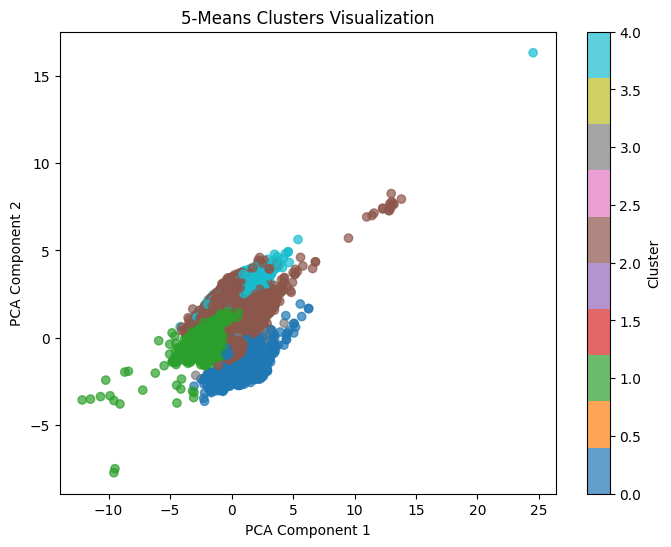

In [14]:
# Do PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot results
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_cluster_clean['cluster'], cmap='tab10', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('5-Means Clusters Visualization')
plt.colorbar(label='Cluster')
plt.show()

In [16]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

%matplotlib qt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=df_cluster_clean['cluster'], cmap='tab10', alpha=0.7)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.show()